# Blazar Population ML – Part 2: Apparent Jet Velocity Regression (MOJAVE Cross-Match)

**Table of Content**

12. [Introduction – Part 2](#12-introduction)
13. Setup and imports
14. EDA – Part 2
15. Regression Setup
<!-- 20. Conclusion - Part 2 -->

## 12. Introduction

### About this Project – Part 2

[Part 1](./blazar_population_ml-p1.ipynb) established the cluster geometry of the full 4LAC-DR3 blazar population and assigned probabilistic classifications to BCU sources using unsupervised methods. Part 2 (this notebook) shifts to supervised regression: given the 334-source MOJAVE-matched subsample, can a model predict the apparent jet velocity $\log \beta_{\rm app}$ from purely observational SED features?

The feature set expands beyond [Part 1](./blazar_population_ml-p1.ipynb). Appended kinematic observables $\beta_{\rm app}$ and $\Gamma_{\rm min} = \sqrt{1 + \beta_{\rm app}^2}$ from MOJAVE-XVII (Lister et al. 2021) are the same quantities used in the forward model of Rueda-Becerril, Harrison & Giannios (2021, RHG21 hereafter). This is the direct observational link between the simulation constraints and the data-driven approach.

**Scientific question:** Does the 4LAC-DR3 SED feature space encode sufficient information to predict the apparent jet velocity $\log \beta_{\rm app}$ in MOJAVE-detected blazars? If so, which SED features carry the predictive signal? Predicting $\log \beta_{\rm app}$ from SED morphology tests whether the blazar sequence in feature space is a reliable individual-source kinematic proxy. The question of recovering the baryon loading $\mu$ directly from observations is addressed in [Part 3](./blazar_population_ml-p3.ipynb), where Tleco pseudo-labels provide the necessary $\mu$ supervision.

Because $\beta_{\rm app}$ is a direct VLBI measurement and is physically linked to $\Gamma$ (and therefore to $\mu$ through $\sigma$), predicting $\log \beta_{\rm app}$ from SED features is the most honest supervised regression question answerable with this dataset. Whether the recovered velocity distribution is consistent with the RHG21 kinematic regime is discussed in Sec. 18.

## 13. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel

# Paths
DATA_DIR = Path("data/")
LAC_H = DATA_DIR / "table-4LAC-DR3-h.fits"
MOJAVE = DATA_DIR / "VizieR-MOJAVE-XVII.fit"

# Plot style
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
CLASS_COLORS = {"bll": "steelblue", "fsrq": "tomato", "bcu": "green"}
SED_COLORS = {"lsp": "tomato", "isp": "goldenrod", "hsp": "steelblue"}

In [2]:
# Load Part 2 parquet
matched_df = pd.read_parquet("data/part2_4lac_mojave.parquet")
print(matched_df.info())
matched_df.describe().round(2)

<class 'pandas.DataFrame'>
RangeIndex: 334 entries, 0 to 333
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   source_name      334 non-null    str    
 1   mojave_id        334 non-null    str    
 2   class            334 non-null    str    
 3   sed_class        334 non-null    str    
 4   redshift         301 non-null    float64
 5   pl_index         334 non-null    float64
 6   lp_alpha         334 non-null    float64
 7   lp_beta          334 non-null    float64
 8   log_nu_syn       327 non-null    float64
 9   log_nuFnu_syn    327 non-null    float64
 10  log_he_epeak     318 non-null    float64
 11  log_compton_dom  312 non-null    float64
 12  log_gamma_lum    301 non-null    float64
 13  var_index        334 non-null    float64
 14  frac_var         320 non-null    float64
 15  beta_app         334 non-null    float64
 16  e_beta           334 non-null    float64
 17  gamma_min        334 non-nu

,redshift,pl_index,lp_alpha,lp_beta,log_nu_syn,log_nuFnu_syn,log_he_epeak,log_compton_dom,log_gamma_lum,var_index,frac_var,beta_app,e_beta,gamma_min,sep_arcsec
count,301.00,334.00,334.00,334.00,327.00,327.00,318.00,312.00,301.00,334.00,320.00,334.00,334.00,334.00,334.00
mean,0.93,2.33,2.26,0.10,13.10,-11.41,2.36,0.14,46.51,1508.43,0.68,7.92,0.82,8.27,0.01
std,0.64,0.23,0.25,0.09,0.80,0.47,0.86,0.49,1.14,6727.74,0.38,8.69,1.03,8.41,0.03
min,0.00,1.68,1.57,-0.11,11.32,-12.49,-0.51,-1.50,41.81,4.95,0.03,0.00,0.00,1.00,0.00
25%,0.42,2.19,2.11,0.06,12.62,-11.73,1.96,-0.20,45.95,55.33,0.41,0.22,0.05,1.02,0.01
50%,0.86,2.34,2.26,0.09,12.92,-11.46,2.30,0.09,46.72,264.32,0.60,5.34,0.52,5.43,0.01
75%,1.34,2.48,2.42,0.12,13.30,-11.13,2.76,0.47,47.25,900.23,0.89,12.56,1.10,12.60,0.02
max,3.10,2.90,3.03,1.00,16.34,-9.66,6.12,1.84,48.68,84340.76,2.29,41.50,7.30,41.51,0.54


In [3]:
print(f"\nCLASS breakdown:")
print(matched_df["class"].value_counts())

print(f'\nbeta_app = 0 sources: {(matched_df["beta_app"] == 0).sum()}')

print(f'\ngamma_min stats:\n{matched_df["gamma_min"].describe().round(2)}')


CLASS breakdown:
class
fsrq     200
bll      110
rdg        8
bcu        8
nlsy1      4
css        2
agn        1
ssrq       1
Name: count, dtype: int64

beta_app = 0 sources: 71

gamma_min stats:
count    334.00
mean       8.27
std        8.41
min        1.00
25%        1.02
50%        5.43
75%       12.60
max       41.51
Name: gamma_min, dtype: float64


## 14. Exploratory Data Analysis

The MOJAVE-XVII cross-match introduces a strong kinematic selection bias: MOJAVE targets bright, compact, flat-spectrum sources with high apparent velocities, which preferentially selects FSRQs and low-frequency-peaked BL Lacs over the high-synchrotron-peaked (HSP) population. Before proceeding to regression, we characterize this bias explicitly. Since the regression model will be trained on this subsample, the generalizability of any recovered $\log \beta_{\rm app}$ prediction depends directly on how representative the subsample is of the full blazar population.

In [4]:
# Load pca_df for UMAP overlay and catalog-level KDE
pca_df = pd.read_parquet("data/pca_catalog.parquet")
pca_df["in_mojave"] = pca_df["source_name"].isin(matched_df["source_name"])
mojave_in_pca = pca_df[pca_df["in_mojave"]]

# Build full palette: known classes get CLASS_COLORS
_all_cls = matched_df["class"].unique()
_palette = {cls: CLASS_COLORS.get(cls, "gray") for cls in _all_cls}

### 1. $\Gamma_{\rm min}$ distribution by CLASS

FSRQs are expected to dominate the high-$\Gamma_{\rm min}$ tail, reflecting the MOJAVE kinematic selection threshold.

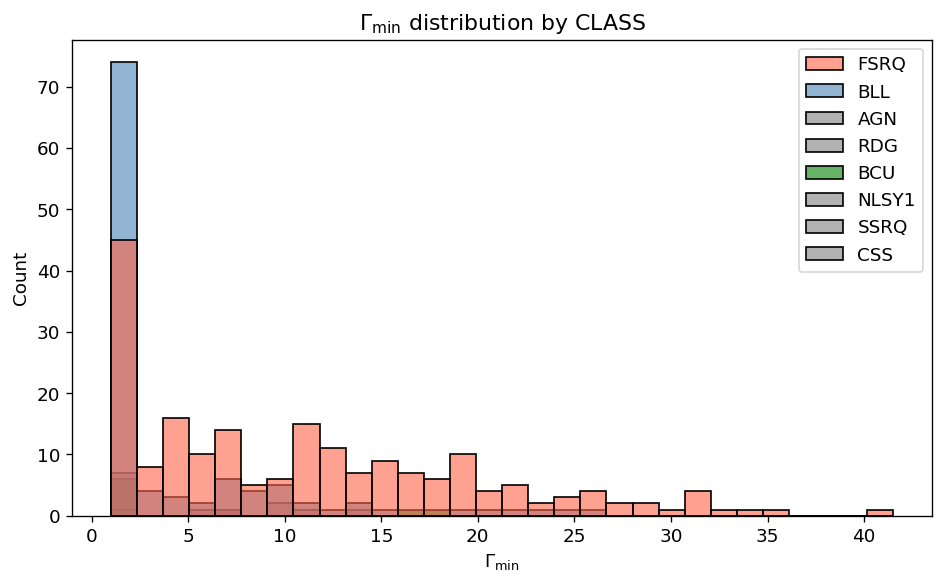

In [5]:
# 1. gamma_min by CLASS
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    data=matched_df,
    x="gamma_min",
    hue="class",
    bins=30,
    alpha=0.6,
    multiple="layer",
    palette=_palette,
    ax=ax,
)
leg = ax.get_legend()
leg.set_title("")
for t in leg.get_texts():
    t.set_text(t.get_text().upper())
ax.set_xlabel(r"$\Gamma_{\rm min}$")
ax.set_ylabel("Count")
ax.set_title(r"$\Gamma_{\rm min}$ distribution by CLASS")

plt.tight_layout()
plt.show()

### 2. $\beta_{\rm app}$ vs. $\log \nu_{\rm syn}$

The kinematic-SED anti-correlation expected from the blazar sequence and the RHG21 model.

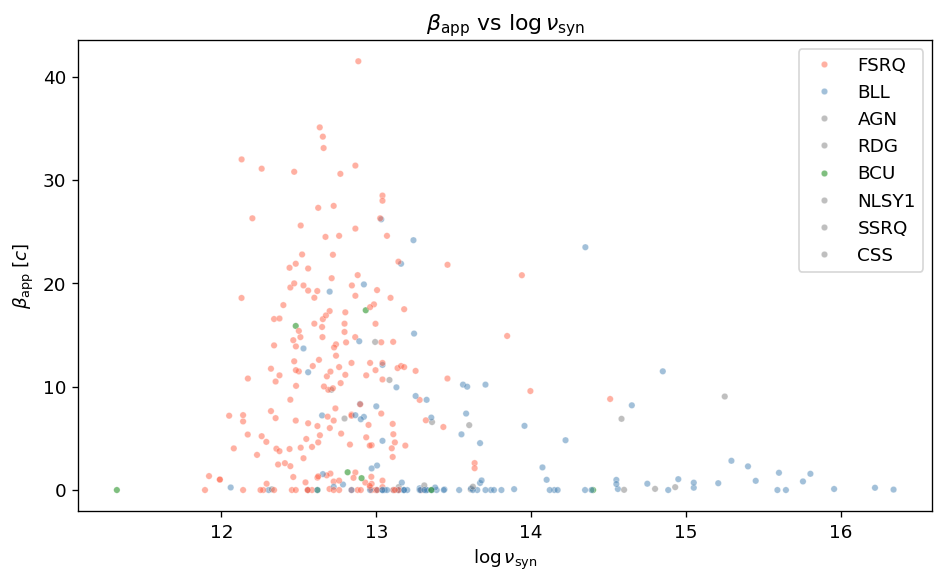

In [6]:
# 2. beta_app vs log_nu_syn
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=matched_df,
    x="log_nu_syn",
    y="beta_app",
    hue="class",
    s=15,
    alpha=0.5,
    palette=_palette,
    ax=ax,
)
leg = ax.get_legend()
leg.set_title("")
for t in leg.get_texts():
    t.set_text(t.get_text().upper())
ax.set_xlabel(r"$\log \nu_{\rm syn}$")
ax.set_ylabel(r"$\beta_{\rm app}\;[c]$")
ax.set_title(r"$\beta_{\rm app}$ vs $\log\nu_{\rm syn}$")

plt.tight_layout()
plt.show()

### 3. Part 2 sources in the Part 1 UMAP embedding

Whether the MOJAVE subsample occupies the full parameter space or is concentrated in the FSRQ/LSP region.

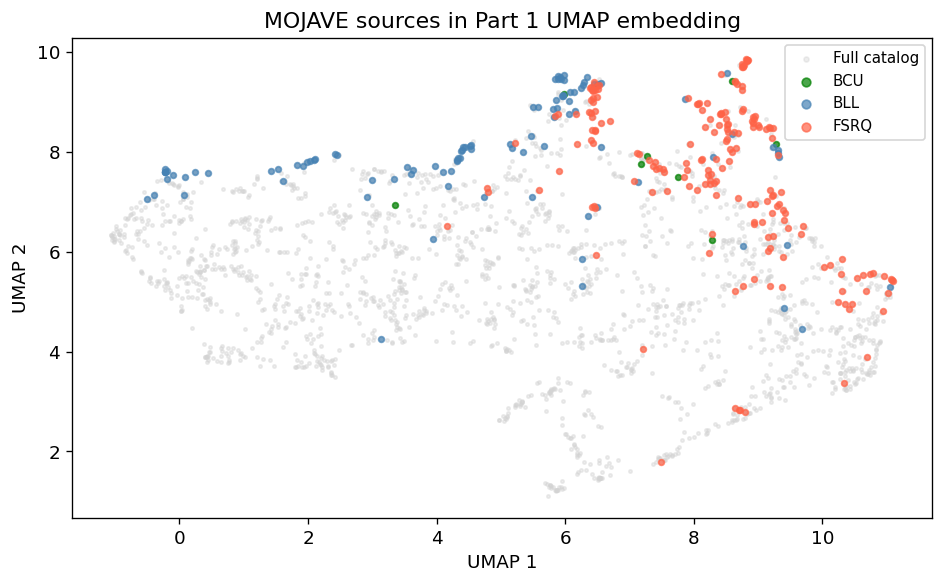

In [7]:
# 3. UMAP overlay: full catalog + MOJAVE subsample
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    pca_df["UMAP1"],
    pca_df["UMAP2"],
    c="lightgray",
    s=4,
    alpha=0.4,
    rasterized=True,
    label="Full catalog",
)
for cls, grp in mojave_in_pca.groupby("class"):
    ax.scatter(
        grp["UMAP1"],
        grp["UMAP2"],
        s=12,
        alpha=0.7,
        color=CLASS_COLORS.get(cls, "gray"),
        label=cls.upper(),
    )
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("MOJAVE sources in Part 1 UMAP embedding")
ax.legend(markerscale=1.5, fontsize=9)

plt.tight_layout()
plt.show()

### 4. $\log \nu_{\rm syn}$ distribution, MOJAVE subsample vs. full 4LAC-DR3 complete-case catalog

The feature most sensitive to the FSRQ/BL Lac split and the primary observable linking the blazar sequence to the baryon loading constraint.

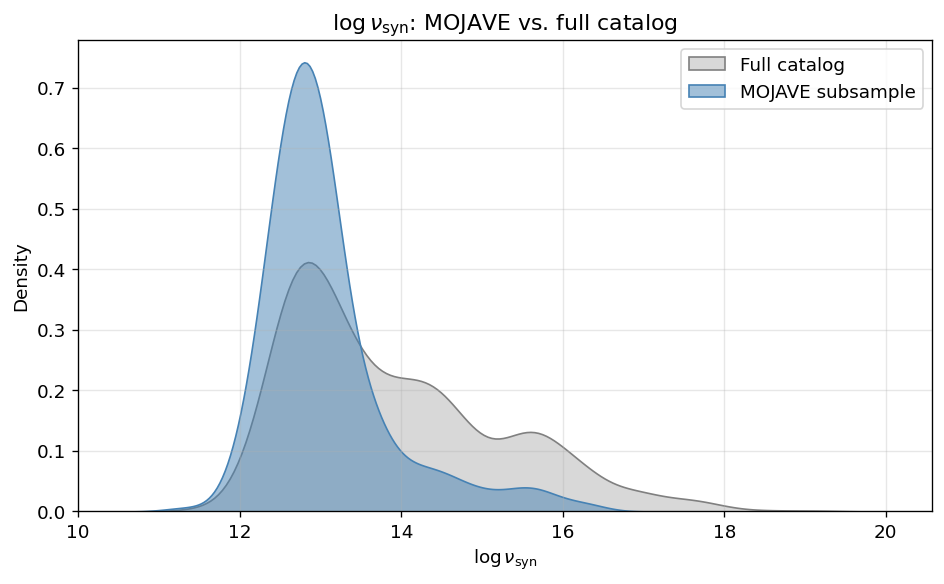

In [8]:
# 4. log_nu_syn KDE: full catalog vs MOJAVE subsample
fig, ax = plt.subplots(figsize=(8, 5))
sns.kdeplot(
    data=pca_df,
    x="log_nu_syn",
    fill=True,
    alpha=0.3,
    color="gray",
    label="Full catalog",
    ax=ax,
)
sns.kdeplot(
    data=mojave_in_pca,
    x="log_nu_syn",
    fill=True,
    alpha=0.5,
    color="steelblue",
    label="MOJAVE subsample",
    ax=ax,
)
ax.set_xlabel(r"$\log \nu_{\rm syn}$")
ax.set_ylabel("Density")
ax.set_title(r"$\log \nu_{\rm syn}$: MOJAVE vs. full catalog")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Diagnostic

The four diagnostics confirm a pronounced selection bias in the MOJAVE subsample:

- **Panel 1**: FSRQs dominate the high-$\Gamma_{\rm min}$ tail, as expected from MOJAVE's kinematic threshold, corresponding to bright, fast-moving jets associated with high-accretion-rate sources.
- **Panel 2**: The $\beta_{\rm app}$ vs. $\log \nu_{\rm syn}$ scatter reproduces the anti-correlation predicted by the blazar sequence and the RHG21 model, with FSRQs clustering at low $\log \nu_{\rm syn}$ and high apparent velocities, and BL Lacs at high $\log \nu_{\rm syn}$ and low $\beta_{\rm app}$.
- **Panel 3**: The Uniform Manifold Approximation and Projection (UMAP) overlay makes the spatial extent of this bias explicit, i.e., the MOJAVE sources are heavily concentrated in the FSRQ/LSP region (see Sec. 9.3 in [Part 1](./blazar_population_ml-p1.ipynb)) embedding and largely absent from the HSP BL Lac locus.
- **Panel 4**: The $\log \nu_{\rm syn}$ kernel density estimate shows that while both distributions share a similar peak, the MOJAVE subsample is narrower and systematically underrepresents the high-$\log \nu_{\rm syn}$ tail where HSP BL Lacs reside.

In addition, we found in [Part 1](./blazar_population_ml-p1.ipynb) that out of the 334 MOJAVE-matched sources, 300 have complete-case Principal Component Analysis (PCA) features and therefore appear in the UMAP embedding. The remaining 34 were dropped in Sec. 7 "Missingness Audit" in Part 1.

The consequence for regression is direct: the model will be trained on a sample that is roughly 60% FSRQs and undersamples the HSP BL Lac population by a large margin. Predictions for high-$\log \nu_{\rm syn}$ sources should be treated as extrapolations beyond the training distribution. This limitation does not invalidate the regression, but it must be stated explicitly when interpreting whether the recovered $\log \beta_{\rm app}$ predictions generalize to the full blazar population.

## 15. Regression Setup

### Target Variable

The regression target is $\log \beta_{\rm app}$, the base-10 logarithm of the apparent jet velocity. $\beta_{\rm app}$ is a direct VLBI measurement from MOJAVE-XVII, not a derived quantity. The log transform is applied for two reasons: (1) $\beta_{\rm app}$ ranges from sub-luminal values to $\sim 40c$, producing a strongly right-skewed distribution; (2) the RHG21 physical picture is formulated in terms of $\Gamma$, which relates to $\beta_{\rm app}$ monotonically, and the $\dot{m}$-$\Gamma$ empirical relation is a power law, so log space is the natural scale for the regression.

Sources with $\beta_{\rm app} = 0$ are excluded: 71 such sources have no detected superluminal motion in MOJAVE, making $\log \beta_{\rm app}$ undefined. These are not slow jets; they are sources where MOJAVE resolved no moving components above the detection threshold, and their exclusion is a data quality cut, not a physical selection.

The baryon loading $\mu$ is not directly observable and has no catalog labels. Recovering $\mu$ requires Tleco pseudo-labels generated from a physical model grid. This is addressed in [Part 3](./blazar_population_ml-p3.ipynb).

### Feature Set

We use seven SED features: the same catalog-native features from Part 1. $\beta_{\rm app}$ and $\Gamma_{\rm min}$ are excluded from the feature set: $\beta_{\rm app}$ is the regression target and $\Gamma_{\rm min} = \sqrt{1 + \beta_{\rm app}^2}$ is a deterministic transform of it. Sources missing any of the seven SED features are dropped (complete-case).

In [9]:
# Seven SED features: the same catalog-native features used in Part 1.
# beta_app and gamma_min are excluded: beta_app is the regression target,
# and gamma_min = sqrt(1 + beta_app^2) is a deterministic transform of it.
reg_feats = [
    "pl_index",
    "lp_alpha",
    "lp_beta",
    "log_nu_syn",
    "log_nuFnu_syn",
    "log_compton_dom",
    "var_index",
]
TARGET = "log_beta_app"

# Exclude beta_app = 0 sources: log(0) is undefined and these sources have
# no detected superluminal motion in MOJAVE (data quality cut, not physical).
reg_df = matched_df[matched_df["beta_app"] > 0].copy()
reg_df["log_beta_app"] = np.log10(reg_df["beta_app"])
print(f'Removed {(matched_df["beta_app"] == 0).sum()} sources with beta_app=0')
print(f'log_beta_app range: [{reg_df["log_beta_app"].min():.2f}, {reg_df["log_beta_app"].max():.2f}]')

# Complete-case filter on SED features
reg_mask = reg_df[reg_feats].notna().all(axis=1)
reg_df = reg_df[reg_mask].reset_index(drop=True)
print(f"Regression sample (complete cases): {len(reg_df)} sources")
print(f'CLASS breakdown:\n{reg_df["class"].value_counts()}')

Removed 71 sources with beta_app=0
log_beta_app range: [-1.71, 1.62]
Regression sample (complete cases): 246 sources
CLASS breakdown:
class
fsrq     168
bll       62
rdg        5
nlsy1      4
bcu        4
css        2
ssrq       1
Name: count, dtype: int64


### Train/Test Split

With ~246 usable sources after exclusions, an 80/20 stratified split by CLASS gives a test set of ~49 sources. This is small enough that reported metrics will have high variance; confidence intervals on all scores are reported via bootstrap where applicable.

An alternative is leave-one-out cross-validation (LOO-CV), which uses every observation once as a test point and is nearly unbiased at this sample size. For Gaussian Process Regression (GPR), LOO-CV is computationally tractable and preferred. For Random Forest, 5-fold cross-validation is the practical choice.

Both approaches are implemented below. The primary evaluation metric is root mean squared error (RMSE) on $\log \beta_{\rm app}$ and the calibration of predictive uncertainty intervals.

**Note on stratification.** The MOJAVE cross-match contains rare source classes beyond BLL, FSRQ, and BCU (`agn`, `ssrq` with fewer than 2 members each). Passing `stratify=classes` directly to `train_test_split` raises a `ValueError` because sklearn requires at least 2 members per stratum. Collapsing rare classes into `"other"` before stratifying is the correct fix: it preserves proportional CLASS balance for the three main classes, which matter because $\log \beta_{\rm app}$ correlates strongly with CLASS (FSRQs systematically show higher apparent velocities than BL Lacs). Dropping stratification entirely (`stratify=None`) is simpler but risks a skewed split that inflates or deflates reported metrics.

In [ ]:
# Arrays for sklearn
X = reg_df[reg_feats].values
y = reg_df[TARGET].values
classes = reg_df["class"].to_numpy()

# Rare classes (agn, ssrq) have <2 members and raise ValueError if we split with
# stratify=classes.
# Collapsing them into 'other' class so main classes (bll, fsrq, bcu) remain stratified
_counts = pd.Series(classes).value_counts()
strat_key = np.where(np.isin(classes, _counts[_counts >= 3].index), classes, "other")

# 80/20 split stratified on main classes
X_train, X_test, y_train, y_test, cls_train, cls_test = train_test_split(
    X, y, classes, test_size=0.2, random_state=42, stratify=strat_key
)

# Standardize features (GPR and RF are scale-sensitive)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Verify split and class balance
print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Train CLASS breakdown: {dict(zip(*np.unique(cls_train, return_counts=True)))}")
print(f"Test CLASS breakdown:  {dict(zip(*np.unique(cls_test, return_counts=True)))}")

Train: 196 | Test: 50
Train CLASS breakdown: {'bcu': np.int64(3), 'bll': np.int64(50), 'css': np.int64(1), 'fsrq': np.int64(134), 'nlsy1': np.int64(3), 'rdg': np.int64(4), 'ssrq': np.int64(1)}
Test CLASS breakdown:  {'bcu': np.int64(1), 'bll': np.int64(12), 'css': np.int64(1), 'fsrq': np.int64(34), 'nlsy1': np.int64(1), 'rdg': np.int64(1)}


## 16. Baseline: Random Forest Regression

Random Forest provides a non-parametric baseline and produces feature importances that can be compared against the physical expectation: $\log \beta_{\rm app}$ should be most predictable from $\log \nu_{\rm syn}$ and Compton dominance ($A_C$), which are the primary axes of the blazar sequence. The Random Forest importances are compared to the length scales learned by the Gaussian Process Regression (GPR) kernel in Sec. 17 to check consistency between the two methods.

Random Forest RMSE: 0.566


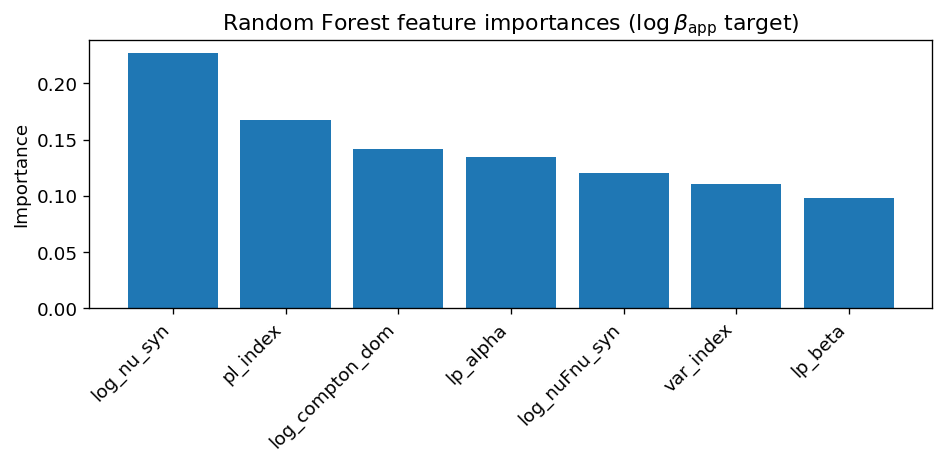

In [11]:
# Baseline Random Forest on SED features
rf = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
rf.fit(X_train_s, y_train)
y_pred_rf = rf.predict(X_test_s)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"Random Forest RMSE: {rmse_rf:.3f}")

# Feature importances
fig, ax = plt.subplots(figsize=(8, 4))
importances = rf.feature_importances_
order = np.argsort(importances)[::-1]
ax.bar(range(len(reg_feats)), importances[order])
ax.set_xticks(range(len(reg_feats)))
ax.set_xticklabels([reg_feats[i] for i in order], rotation=45, ha="right")
ax.set_ylabel("Importance")
ax.set_title(r"Random Forest feature importances ($\log \beta_{\rm app}$ target)")
plt.tight_layout()
plt.show()

## 17. Gaussian Process Regression

Gaussian Process Regression (GPR) is the preferred method at this sample size for three reasons:

1. Principled uncertainty quantification. The posterior predictive distribution provides per-source confidence intervals, which is essential for characterizing the SED-kinematic relationship at the individual-source level and propagating uncertainty into the interpretation in Sec. 18.

2. Exact inference at ~246 samples is tractable ($O(n^3)$ scaling).

3. Interpretable kernel. The length scales learned by the radial basis function (RBF) kernel quantify which features drive variation in $\log \beta_{\rm app}$, providing a physically interpretable summary of the regression that can be compared directly against the RHG21 forward model.

The kernel is an RBF with per-feature length scales (Automatic Relevance Determination, ARD) plus a white noise term. ARD length scales invert feature importance: a short length scale means the output varies rapidly with that feature (high importance). The noise term absorbs measurement scatter and residual variation not captured by the features.

Hyperparameter optimization is performed by maximizing the marginal likelihood (log-likelihood of the training data integrated over the latent function). This is built into `sklearn.gaussian_process.GaussianProcessRegressor`.

In [12]:
n_feats = len(reg_feats)
kernel = ConstantKernel(1.0) * RBF(length_scale=np.ones(n_feats)) + WhiteKernel(noise_level=0.1)

gpr = GaussianProcessRegressor(
    kernel=kernel, n_restarts_optimizer=10, normalize_y=True, random_state=42
)
gpr.fit(X_train_s, y_train)
y_pred_gpr, y_std_gpr = gpr.predict(X_test_s, return_std=True)
rmse_gpr = np.sqrt(mean_squared_error(y_test, y_pred_gpr))

print("── Gaussian Process Regression (SED → log β_app) ───────")
print(f"RMSE: {rmse_gpr:.3f}")
print(f"Optimized kernel: {gpr.kernel_}")
within_1s = np.mean(np.abs(y_test - y_pred_gpr) <= y_std_gpr)
within_2s = np.mean(np.abs(y_test - y_pred_gpr) <= 2 * y_std_gpr)
print(f"Coverage 1σ: {within_1s:.2%} (expect ~68%)  |  2σ: {within_2s:.2%} (expect ~95%)")

── Gaussian Process Regression (SED → log β_app) ───────
RMSE: 0.570
Optimized kernel: 0.76**2 * RBF(length_scale=[1.29e+03, 0.181, 3.61e+04, 1.76, 3.11, 3.3, 2.37]) + WhiteKernel(noise_level=0.623)
Coverage 1σ: 74.00% (expect ~68%)  |  2σ: 94.00% (expect ~95%)


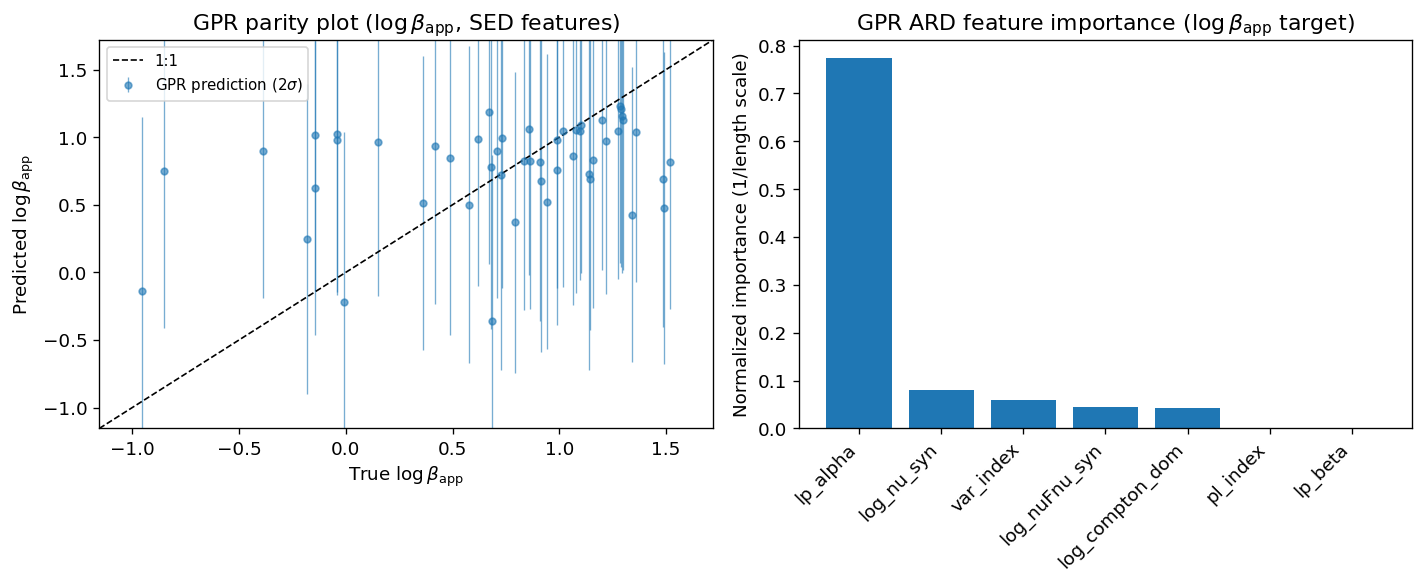

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel 1: Parity plot
ax = axes[0]
ax.errorbar(
    y_test,
    y_pred_gpr,
    yerr=2 * y_std_gpr,
    fmt="o",
    alpha=0.6,
    markersize=4,
    elinewidth=0.8,
    label=r"GPR prediction (2$\sigma$)",
)
lim = [
    min(y_test.min(), y_pred_gpr.min()) - 0.2,
    max(y_test.max(), y_pred_gpr.max()) + 0.2,
]
ax.plot(lim, lim, "k--", lw=1, label="1:1")
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel(r"True $\log \beta_{\rm app}$")
ax.set_ylabel(r"Predicted $\log \beta_{\rm app}$")
ax.set_title(r"GPR parity plot ($\log \beta_{\rm app}$, SED features)")
ax.legend(fontsize=9)

# Panel 2: ARD length scales (inverted = importance)
ax = axes[1]
def _find_rbf(kernel):
    if isinstance(kernel, RBF):
        return [kernel]
    result = []
    for attr in ('k1', 'k2'):
        sub = getattr(kernel, attr, None)
        if sub is not None:
            result += _find_rbf(sub)
    return result

rbf_kernel = _find_rbf(gpr.kernel_)
if rbf_kernel:
    ls = rbf_kernel[0].length_scale
    importance = 1.0 / ls
    importance /= importance.sum()
    order = np.argsort(importance)[::-1]
    ax.bar(range(len(reg_feats)), importance[order])
    ax.set_xticks(range(len(reg_feats)))
    ax.set_xticklabels([reg_feats[i] for i in order], rotation=45, ha="right")
    ax.set_ylabel("Normalized importance (1/length scale)")
    ax.set_title(r"GPR ARD feature importance ($\log \beta_{\rm app}$ target)")

plt.tight_layout()
plt.show()